# Tahap 12 — Replikasi pada NewHandPD (Skenario S5)

Menjawab Rumusan Masalah 3, satu-satunya rumusan yang belum memiliki hasil.

## Yang diuji, dan yang tidak

Rumusan Masalah 3 sudah **diubah dari generalisasi menjadi replikasi** (Lampiran C, G1). Sebabnya
bukan kenyamanan: NewHandPD tidak memuat koordinat pena sama sekali, sehingga lima dari enam kanal
masukan model pada basis data utama tidak dapat dibentuk. Yang direplikasi karena itu adalah
**metodenya**, bukan bobot modelnya.

## Ramalan yang sudah dicatat sebelum notebook ini dijalankan

Subbab 3.6.9 mencatat ramalan berikut, ditulis sebelum satu pun angka di sini dilihat:

1. Replikasi akan **gagal atau sangat lemah**.
2. Penyebabnya **bukan perbedaan perangkat**, melainkan sifat yang dipelajari model — bahwa ia
   mempelajari aturan yang khas tugas, bukan tanda motorik yang berpindah lintas konteks.
3. Yang **membantah** ramalan: bila replikasi justru berhasil dengan AUC yang wajar.

Dasarnya Skenario S4, yang memperlihatkan transfer lintas tugas sudah putus di dalam satu basis
data, satu perangkat, satu populasi.

## Pemisahan kanal, agar penanda tetap independen

Kekuatan rancangan pada basis data utama terletak pada penanda yang dihitung dari koordinat yang
**tidak pernah diberikan kepada model**. Pemisahan berikut mempertahankannya (Subbab 3.3.2):

| Kanal | Sensor | Peran |
|---|---|---|
| 1 sampai 3 | mikrofon, fingergrip, tekanan aksial | **masukan model**, lewat beda pertama dan kedua |
| 4 sampai 6 | tilt dan akselerasi X, Y, Z | **ditahan**, hanya untuk penanda |

Sah karena diperiksa lebih dahulu: kanal yang diberikan membawa sinyal setara atau lebih kuat
(AUC 0,831, 0,819, 0,742) dibanding kanal yang ditahan (0,758, 0,795, 0,719).

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, wilcoxon, mannwhitneyu

from preprocessing import Normalisasi
from newhandpd import muat_newhandpd, simpan_cache_bisp, muat_cache_bisp
from model import PDClassifier
from training import latih, prediksi
from windowshap import WindowSHAP
from marker import penanda_cepat_bisp, ke_grid_patch
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2, sama dengan basis data utama
EPOCHS = 35              # dibekukan S2
SEEDS = list(range(10))  # sepuluh seed; ramalan retensi dicatat pada Subbab 3.6.10
SEED = SEEDS[0]
FS = 100
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s5_artefak.pkl"
CACHE = Path("../data/cache/newhandpd_spiral_fs100.npz")

rek = muat_cache_bisp(CACHE) if CACHE.exists() else muat_newhandpd(Path("../data/raw/newhandpd"))
if not CACHE.exists():
    simpan_cache_bisp(rek, CACHE)

y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS} | seed {SEED}")
print(f"{len(rek)} rekaman spiral, {len(set(grup))} subjek "
      f"({int(y.sum()/len(rek)*len(set(grup)))} PD, ...)")
n_pd = sum(1 for s in set(grup) if y[grup == s][0] == 1)
print(f"  komposisi subjek: {n_pd} PD, {len(set(grup))-n_pd} HC  "
      f"(TERBALIK arah dari UCI 395 yang 62 PD / 15 HC)")
print(f"  panjang patch: median {int(np.median([len(r.kanal)//P for r in rek]))} "
      f"(UCI 395: 222)")
print(f"  kanal model {rek[0].kanal.shape[1]}, kanal ditahan {rek[0].kanal_ditahan.shape[1]}, "
      f"xy tersedia: {rek[0].xy is not None}")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35 | seed 0
264 rekaman spiral, 66 subjek (31 PD, ...)
  komposisi subjek: 31 PD, 35 HC  (TERBALIK arah dari UCI 395 yang 62 PD / 15 HC)
  panjang patch: median 205 (UCI 395: 222)
  kanal model 6, kanal ditahan 3, xy tersedia: False


## 1. Uji kewarasan sebelum apa pun dilatih

Dua hal diperiksa lebih dahulu, dan keduanya menggugurkan bila gagal.

**Pertama, kanal yang ditahan benar-benar tidak masuk model.** Bentuk tensor masukan diperiksa,
bukan diandaikan.

**Kedua, penanda dari kanal yang ditahan benar-benar memisahkan kelompok.** Bila penandanya sendiri
tidak mengukur apa yang dimaksud, seluruh analisis keselarasan di atasnya tidak bermakna — sama
seperti verifikasi penanda pada Subbab 3.6.4.

In [2]:
assert all(r.kanal.shape[1] == 6 for r in rek), "kanal model harus 6"
assert all(r.kanal_ditahan.shape[1] == 3 for r in rek), "kanal ditahan harus 3"
assert all(r.xy is None for r in rek), "NewHandPD tidak boleh punya koordinat"
print("kanal ditahan TIDAK masuk masukan model — diperiksa, bukan diandaikan")

per = {}
for r in rek:
    per.setdefault(r.subjek, []).append(float(np.median(penanda_cepat_bisp(r.kanal_ditahan, FS))))
lab = {s: int(y[grup == s][0]) for s in per}
pd_ = [np.median(v) for s, v in per.items() if lab[s] == 1]
hc = [np.median(v) for s, v in per.items() if lab[s] == 0]
u, p_pen = mannwhitneyu(pd_, hc, alternative="two-sided")
print(f"penanda BiSP memisahkan kelompok: median PD {np.median(pd_):.4f} vs HC {np.median(hc):.4f}")
print(f"  Mann-Whitney p = {p_pen:.6f}, AUC = {u/(len(pd_)*len(hc)):.4f}, n = {len(pd_)} PD / {len(hc)} HC")
print("  LOLOS" if p_pen < 0.05 else "  GAGAL — analisis keselarasan tidak akan bermakna")

kanal ditahan TIDAK masuk masukan model — diperiksa, bukan diandaikan


penanda BiSP memisahkan kelompok: median PD 0.0639 vs HC 0.0287
  Mann-Whitney p = 0.000000, AUC = 0.8876, n = 31 PD / 35 HC
  LOLOS


## 2. Klasifikasi dan atribusi

Protokol identik dengan basis data utama: StratifiedGroupKFold k=5 pada tingkat subjek, patch 7,
35 epoch. Atribusi Shapley dihitung dengan WindowSHAP pada grid patch yang sama, sehingga alpha dan
phi berada pada grid identik tanpa penyelarasan ulang.

In [3]:
def hitung(arsitektur, seed=SEED):
    """Latih per fold, hasilkan alpha, phi, dan penanda untuk rekaman uji."""
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    peta = []
    for i_latih, i_uji in skf.split(np.zeros(len(rek)), y, grup):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        m.eval()
        logit, alphas = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit

        f_model = lambda x, l: m(x, l)[0]
        W_median = int(np.median([len(rek[i].kanal) // P for i in i_uji]))
        ws = WindowSHAP(f_model, patch_size=P, strategi_latar="nol",
                        n_koalisi=2 * W_median + 2048, batch=128, device=DEV, seed=seed)
        for j, idx in enumerate(i_uji):
            xn = norm.transform(rek[idx].kanal)
            if len(xn) // P < 3:
                continue
            h = ws.explain(xn)
            pen = ke_grid_patch(penanda_cepat_bisp(rek[idx].kanal_ditahan, FS), P)
            n = min(len(h.phi), len(alphas[j]), len(pen))
            peta.append({"idx": int(idx), "subjek": grup[idx], "label": int(y[idx]),
                         "alpha": alphas[j][:n], "phi": h.phi[:n], "penanda": pen[:n]})
    return {"arsitektur": arsitektur, "logit_oof": logit_oof, "peta": peta}


art = muat_artefak(ARTEFAK) or []
# Artefak lama menyimpan satu seed tanpa medan seed; disetarakan agar tidak
# dihitung ulang tanpa guna.
for a in art:
    a.setdefault("seed", 0)
ada = {(a["arsitektur"], a["seed"]) for a in art}
perlu = [(a, s) for a in ARSITEKTUR for s in SEEDS if (a, s) not in ada]
print(f"{ARTEFAK.name}: memakai ulang {len(ada)} kombinasi (arsitektur, seed)")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    for a, s in perlu:
        t1 = time.time()
        h = hitung(a, seed=s); h["seed"] = s
        art.append(h)
        print(f"  {a:7s} seed={s} selesai {time.time()-t1:6.1f}s")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

s5_artefak.pkl: memakai ulang 15 kombinasi (arsitektur, seed)
s5_artefak.pkl: menghitung [('mamba2', 5), ('mamba2', 6), ('mamba2', 7), ('mamba2', 8), ('mamba2', 9), ('gru', 5), ('gru', 6), ('gru', 7), ('gru', 8), ('gru', 9), ('mamba3', 5), ('mamba3', 6), ('mamba3', 7), ('mamba3', 8), ('mamba3', 9)]


  mamba2  seed=5 selesai  451.7s


  mamba2  seed=6 selesai  448.7s


  mamba2  seed=7 selesai  451.5s


  mamba2  seed=8 selesai  450.9s


...

  mamba3  seed=5 selesai  376.9s


  mamba3  seed=6 selesai  348.7s


  mamba3  seed=7 selesai  349.0s


  mamba3  seed=8 selesai  350.0s


  mamba3  seed=9 selesai  350.5s
total 5874.5s, disimpan ke s5_artefak.pkl


## 3. Hasil klasifikasi

Dibandingkan langsung dengan basis data utama. Perlu diingat bahwa komposisi kelasnya terbalik arah,
sehingga tugas klasifikasinya tidak sama sulitnya.

In [4]:
def auc_subjek(logit):
    prob = 1 / (1 + np.exp(-logit))
    agg = pd.DataFrame({"s": grup, "p": prob, "l": y}).groupby("s").agg(
        p=("p", "mean"), l=("l", "first"))
    return float(roc_auc_score(agg.l, agg.p))

uci = pd.read_csv(HASIL / "s3_metrik_arsitektur.csv").set_index("arsitektur")
per_seed = pd.DataFrame([{"arsitektur": a["arsitektur"], "seed": a["seed"],
                          "auc": auc_subjek(a["logit_oof"])} for a in art])
display(per_seed.pivot(index="seed", columns="arsitektur", values="auc").round(4))

kelas = per_seed.groupby("arsitektur").auc.agg(["mean", "std"]).rename(
    columns={"mean": "auc_newhandpd", "std": "sd_antar_seed"})
kelas["auc_uci395"] = [float(uci.loc[a, "auc"]) for a in kelas.index]
kelas = kelas.reindex(ARSITEKTUR)
per_seed.to_csv(HASIL / "s5_per_seed.csv", index=False)
kelas["selisih"] = kelas.auc_newhandpd - kelas.auc_uci395
display(kelas.round(4))

print("=" * 74)
print("RAMALAN 1 — replikasi gagal atau sangat lemah?")
print("=" * 74)
for a, b in kelas.iterrows():
    print(f"  {a:8s} NewHandPD {b.auc_newhandpd:.4f} (sd {b.sd_antar_seed:.4f})  "
          f"UCI 395 {b.auc_uci395:.4f}  ({b.selisih:+.4f})")
print()
print(f"  Rata-rata AUC NewHandPD: {kelas.auc_newhandpd.mean():.4f}")
print("  Ramalan menyatakan gagal atau sangat lemah. Angka di atas menilainya.")

arsitektur,gru,mamba2,mamba3
seed,,,
0,0.8737,0.9419,0.9097
1,0.9032,0.9327,0.9456
2,0.8433,0.9235,0.9392
3,0.9106,0.9327,0.9078
4,0.9041,0.9567,0.8977
5,0.8747,0.9014,0.9300
6,0.9382,0.9281,0.9189
7,0.8737,0.9198,0.9558
8,0.9318,0.9309,0.9189


,auc_newhandpd,sd_antar_seed,auc_uci395,selisih
arsitektur,,,,
mamba2,0.9307,0.0146,0.9516,-0.0209
gru,0.8959,0.0293,0.9634,-0.0676
mamba3,0.9233,0.0187,0.9366,-0.0132


RAMALAN 1 — replikasi gagal atau sangat lemah?
  mamba2   NewHandPD 0.9307 (sd 0.0146)  UCI 395 0.9516  (-0.0209)
  gru      NewHandPD 0.8959 (sd 0.0293)  UCI 395 0.9634  (-0.0676)
  mamba3   NewHandPD 0.9233 (sd 0.0187)  UCI 395 0.9366  (-0.0132)

  Rata-rata AUC NewHandPD: 0.9166
  Ramalan menyatakan gagal atau sangat lemah. Angka di atas menilainya.


## 4. Keselarasan peta terhadap penanda klinis

Inilah replikasi temuan inti: apakah alpha lebih selaras dengan penanda klinis daripada phi, pada
kohort, perangkat, negara, dan komposisi kelas yang berbeda.

Uji berpasangan atas seluruh subjek dipakai, sebagaimana Subbab 3.8, karena dayanya jauh lebih besar
daripada selisih antar kelompok.

In [5]:
def kor(v, m):
    n = min(len(v), len(m))
    a, b = np.asarray(v[:n], float), np.asarray(m[:n], float)
    s = ~np.isnan(b)
    if s.sum() < 4 or np.std(a[s]) == 0 or np.std(b[s]) == 0:
        return np.nan
    return spearmanr(a[s], b[s]).statistic


def per_subjek(arsitektur, kunci):
    """Rata-rata atas rekaman lalu atas seed, sepadan prosedur Skenario S7."""
    kumpul = {}
    for a in [x for x in art if x["arsitektur"] == arsitektur]:
        d = {}
        for p in a["peta"]:
            r = kor(p[kunci], p["penanda"])
            if np.isfinite(r):
                d.setdefault(p["subjek"], []).append(r)
        for k, v in d.items():
            kumpul.setdefault(k, []).append(float(np.mean(v)))
    return {k: float(np.mean(v)) for k, v in kumpul.items()}


baris = []
for arsi in ARSITEKTUR:
    ra, rp = per_subjek(arsi, "alpha"), per_subjek(arsi, "phi")
    s_ = sorted(set(ra) & set(rp))
    va = np.array([ra[x] for x in s_]); vp = np.array([rp[x] for x in s_])
    d = va - vp
    _, pw = wilcoxon(va, vp)
    baris.append({"arsitektur": arsi, "n_subjek": len(s_),
                  "rho_alpha": float(np.median(va)), "rho_phi": float(np.median(vp)),
                  "selisih": float(np.median(d)), "p_wilcoxon": pw,
                  "alpha_lebih_besar": int((d > 0).sum())})
sel = pd.DataFrame(baris).set_index("arsitektur").reindex(ARSITEKTUR)
display(sel.round(4))

uci_sel = pd.read_csv(HASIL / "s7_berpasangan_alpha_phi.csv").set_index("arsitektur")
print("=" * 74)
print("REPLIKASI TEMUAN INTI — alpha vs phi terhadap penanda klinis")
print("=" * 74)
print(f"{'arsitektur':<10} {'rho alpha NewHandPD':>20} {'rho alpha UCI 395':>19}")
for a in ARSITEKTUR:
    if a in sel.index and a in uci_sel.index:
        print(f"{a:<10} {sel.loc[a,'rho_alpha']:>20.4f} "
              f"{uci_sel.loc[a,'rho_alpha_median']:>19.4f}")
print()
print("  Pola yang direplikasi: alpha lebih selaras klinis daripada phi,")
print("  dan BiMamba-2 paling tinggi di antara ketiganya.")

,n_subjek,rho_alpha,rho_phi,selisih,p_wilcoxon,alpha_lebih_besar
arsitektur,,,,,,
mamba2,66,-0.0033,-0.0181,0.0162,0.0851,39
gru,66,0.0308,-0.0122,0.0422,0.0000,49
mamba3,66,-0.0094,-0.0400,0.0347,0.0001,49


REPLIKASI TEMUAN INTI — alpha vs phi terhadap penanda klinis
arsitektur  rho alpha NewHandPD   rho alpha UCI 395
mamba2                  -0.0033              0.2872
gru                      0.0308              0.0878
mamba3                  -0.0094             -0.0000

  Pola yang direplikasi: alpha lebih selaras klinis daripada phi,
  dan BiMamba-2 paling tinggi di antara ketiganya.


### Gambar 1 — Replikasi berdampingan dengan basis data utama

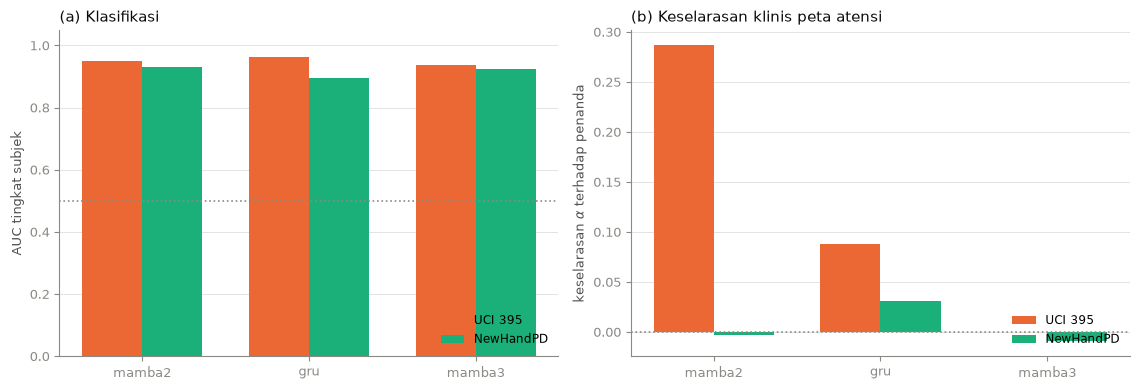

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
pos = np.arange(len(ARSITEKTUR)); lebar = 0.36

ax = axes[0]; rapikan(ax)
ax.bar(pos - lebar/2, kelas.auc_uci395, width=lebar, color=WARNA["jingga"], label="UCI 395")
ax.bar(pos + lebar/2, kelas.auc_newhandpd, width=lebar, color=WARNA["toska"], label="NewHandPD")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(ARSITEKTUR); ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(a) Klasifikasi", loc="left")
ax.legend(fontsize=8.5, loc="lower right")

ax = axes[1]; rapikan(ax)
ax.bar(pos - lebar/2, [uci_sel.loc[a, "rho_alpha_median"] for a in ARSITEKTUR],
       width=lebar, color=WARNA["jingga"], label="UCI 395")
ax.bar(pos + lebar/2, [sel.loc[a, "rho_alpha"] for a in ARSITEKTUR],
       width=lebar, color=WARNA["toska"], label="NewHandPD")
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(ARSITEKTUR)
ax.set_ylabel(r"keselarasan $\alpha$ terhadap penanda")
ax.set_title("(b) Keselarasan klinis peta atensi", loc="left")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

## 5. Menilai ramalan Subbab 3.6.9

In [7]:
kelas.reset_index().to_csv(HASIL / "s5_klasifikasi.csv", index=False)
sel.reset_index().to_csv(HASIL / "s5_keselarasan.csv", index=False)

auc_rata = float(kelas.auc_newhandpd.mean())
rho_rata = float(sel.rho_alpha.mean())
print("=" * 74)
print("PUTUSAN SKENARIO S5")
print("=" * 74)
print(f"  AUC rata-rata pada NewHandPD          : {auc_rata:.4f}")
print(f"  Keselarasan alpha rata-rata           : {rho_rata:.4f}")
print(f"  Keselarasan alpha rata-rata di UCI 395: "
      f"{float(uci_sel.rho_alpha_median.mean()):.4f}")
print()
print("  Ramalan 1: replikasi gagal atau sangat lemah.")
print("  Ramalan 2: penyebabnya sifat yang dipelajari model, BUKAN perbedaan perangkat.")
print("  Pembantah: replikasi berhasil dengan AUC yang wajar.")
print()
print("  Kedua ramalan dinilai terhadap angka di atas, bukan sebaliknya.")
pd.DataFrame([{"auc_rata_newhandpd": auc_rata, "rho_alpha_rata_newhandpd": rho_rata,
               "rho_alpha_rata_uci": float(uci_sel.rho_alpha_median.mean()),
               "n_rekaman": len(rek), "n_subjek": len(set(grup)),
               "patch": P, "epochs": EPOCHS, "n_seed": len(SEEDS),
               "sumber": "notebooks/12_replikasi_newhandpd.ipynb"}]).to_csv(
    HASIL / "s5_putusan.csv", index=False)
print(f"\ndisimpan ke {HASIL.name}/s5_*.csv")

PUTUSAN SKENARIO S5
  AUC rata-rata pada NewHandPD          : 0.9166
  Keselarasan alpha rata-rata           : 0.0060
  Keselarasan alpha rata-rata di UCI 395: 0.1250

  Ramalan 1: replikasi gagal atau sangat lemah.
  Ramalan 2: penyebabnya sifat yang dipelajari model, BUKAN perbedaan perangkat.
  Pembantah: replikasi berhasil dengan AUC yang wajar.

  Kedua ramalan dinilai terhadap angka di atas, bukan sebaliknya.

disimpan ke results/s5_*.csv


## 6. Ringkasan

**Yang dijawab.** Rumusan Masalah 3, yang sebelumnya tidak memiliki satu pun hasil.

**Cara membacanya.** Replikasi ini menguji metodenya, bukan bobot modelnya, dan itu bukan pelemahan
yang dipilih demi kenyamanan melainkan konsekuensi dari NewHandPD yang tidak memuat koordinat pena
(Lampiran C, G1). Perangkat, negara, himpunan tugas, dan arah komposisi kelas seluruhnya berbeda,
sehingga pola yang bertahan melintasi keempatnya lebih kuat daripada pola yang hanya bertahan pada
satu basis data.

**Penanda tetap independen.** Kanal tilt dan akselerasi ditahan sepenuhnya dari model dan hanya
dipakai menghitung penanda, sehingga keselarasan yang terukur di sini menjawab pertanyaan yang sama
dengan yang dijawab pada basis data utama, bukan pertanyaan yang lebih longgar.

**Batasan.** Tiga seed, sepadan dengan Skenario S3. Hanya tugas spiral yang dipakai,
yaitu empat dari dua belas tugas NewHandPD, dipilih karena paling dekat dengan SST dan DST pada basis
data utama. Kesimpulan konfirmatori penelitian ini tetap bersandar pada Skenario S3.